In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("ai_job_replacement_2020_2026_v2.csv")
df.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                      15000 non-null  object 
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_leve

,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,2022.997200,46.176347,46.155907,50.003708,89771.375196,89870.633937,0.114268,5.020461,54.898078,49.798269,3.01540,48.090028,7.986441,35.867584,23.006933
std,4330.271354,1.999365,21.663635,22.351347,28.811040,34522.125434,35897.592992,10.029197,9.956155,25.863593,28.860725,1.40512,18.107573,6.067153,12.416415,18.242259
min,0.000000,2020.000000,5.000000,4.010000,0.000000,30003.690000,19022.670000,-38.370000,-31.880000,10.010000,0.010000,1.00000,2.975000,0.000000,2.456000,0.003714
25%,3749.750000,2021.000000,28.790000,28.357500,25.170000,60127.225000,59223.457500,-6.640000,-1.662500,32.517500,24.707500,2.00000,34.900000,3.210000,26.982250,8.225829
50%,7499.500000,2023.000000,46.235000,45.675000,49.930000,89533.050000,88787.330000,0.150000,4.960000,54.775000,49.435000,3.00000,48.155000,6.665000,35.871000,18.642515
75%,11249.250000,2025.000000,63.602500,62.712500,75.025000,119823.840000,118432.967500,6.690000,11.730000,77.405000,74.795000,4.00000,61.296250,11.550000,44.698500,34.090823
max,14999.000000,2026.000000,94.980000,113.070000,99.980000,149984.060000,191961.210000,36.920000,49.790000,99.990000,99.980000,5.00000,96.340000,38.370000,71.579000,93.351726


In [3]:
df.isna().sum()

,0
job_id,0
job_role,0
industry,0
country,0
year,0
automation_risk_percent,0
ai_replacement_score,0
skill_gap_index,0
salary_before_usd,0
salary_after_usd,0


In [4]:
df_drop = df.dropna()

In [5]:
df_mean = df.copy()
df_mean.fillna(df_mean.mean(numeric_only=True), inplace=True)

In [6]:
df_median = df.copy()
df_median.fillna(df_median.median(numeric_only=True), inplace=True)

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} Outliers:", len(outliers))

job_id Outliers: 0
year Outliers: 0
automation_risk_percent Outliers: 0
ai_replacement_score Outliers: 0
skill_gap_index Outliers: 0
salary_before_usd Outliers: 0
salary_after_usd Outliers: 0
salary_change_percent Outliers: 114
skill_demand_growth_percent Outliers: 116
remote_feasibility_score Outliers: 0
ai_adoption_level Outliers: 0
education_requirement_level Outliers: 0
skill_transition_pressure Outliers: 0
wage_volatility_index Outliers: 244
reskilling_urgency_score Outliers: 2
ai_disruption_intensity Outliers: 163


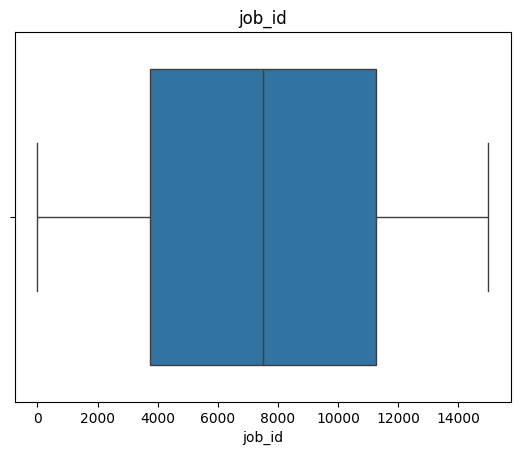

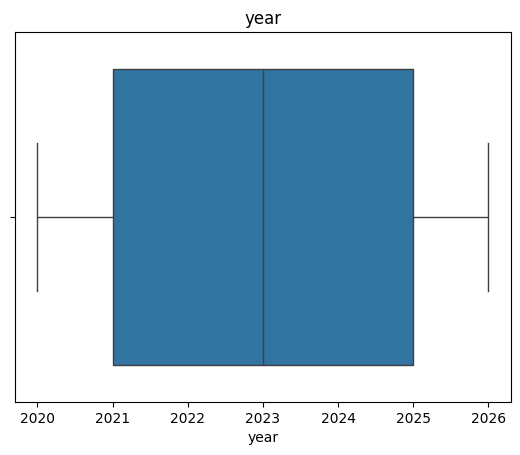

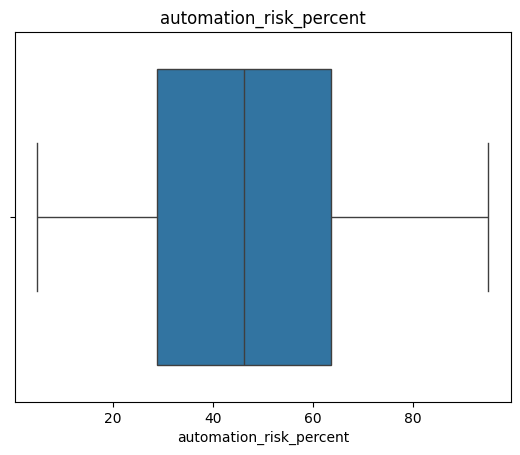

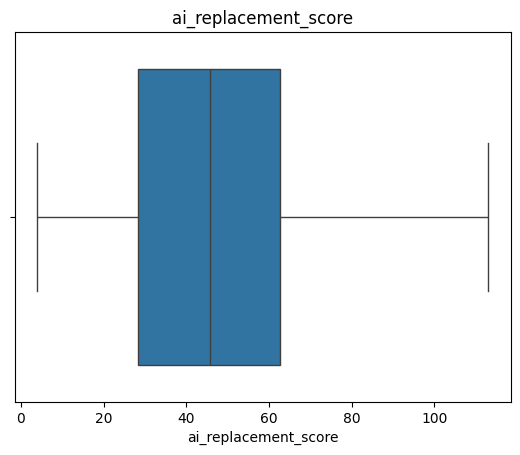

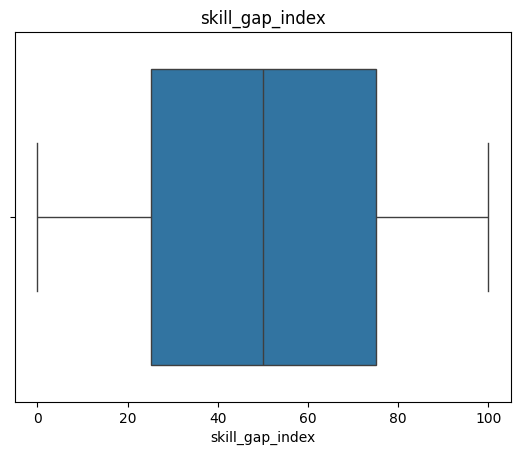

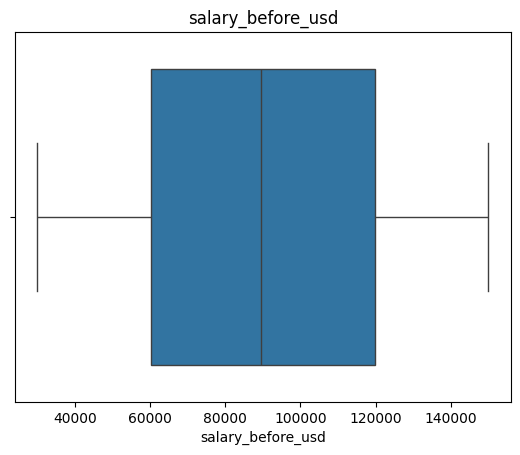

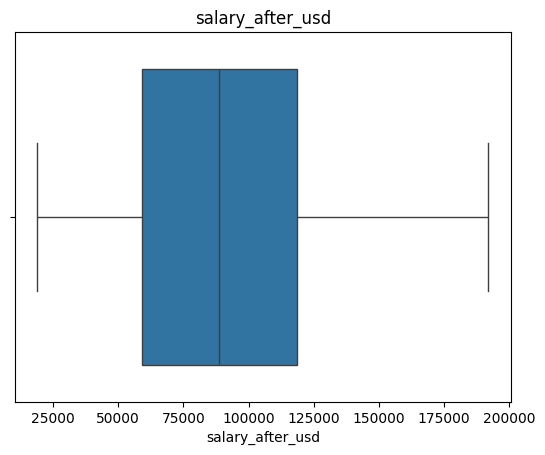

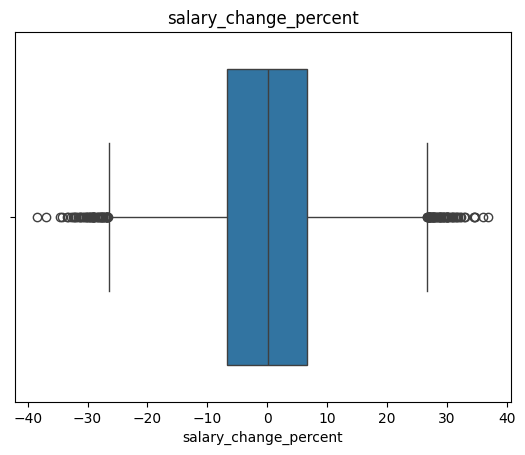

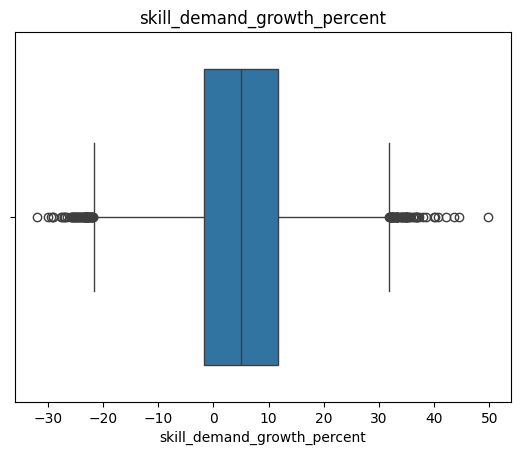

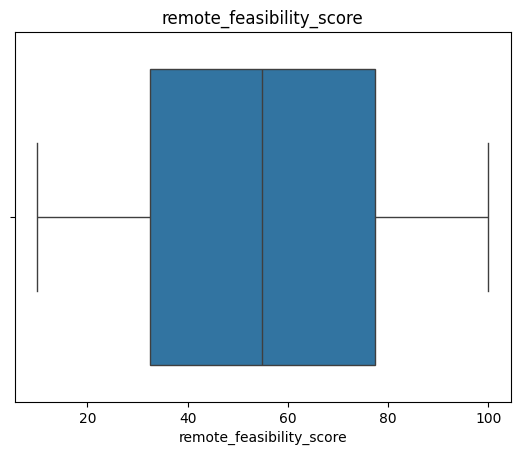

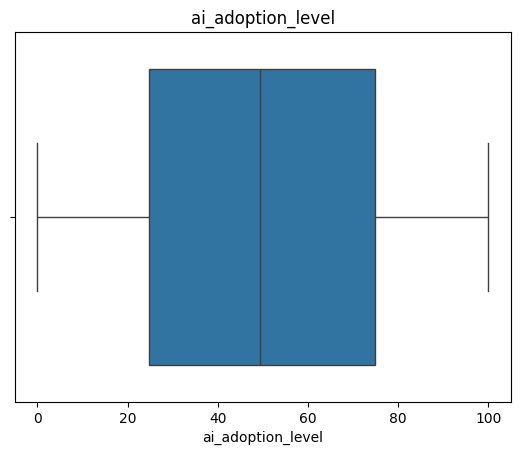

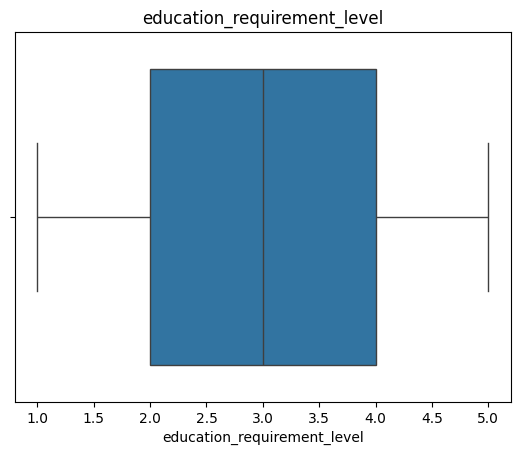

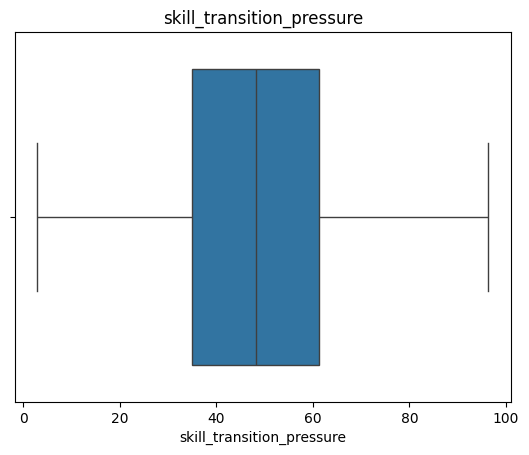

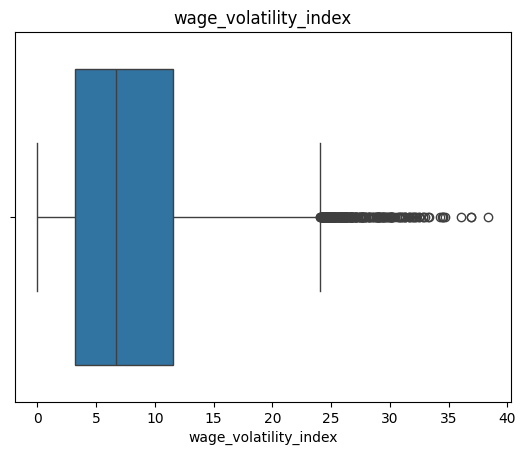

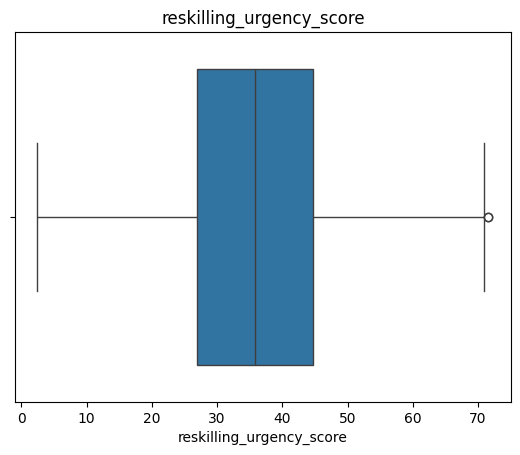

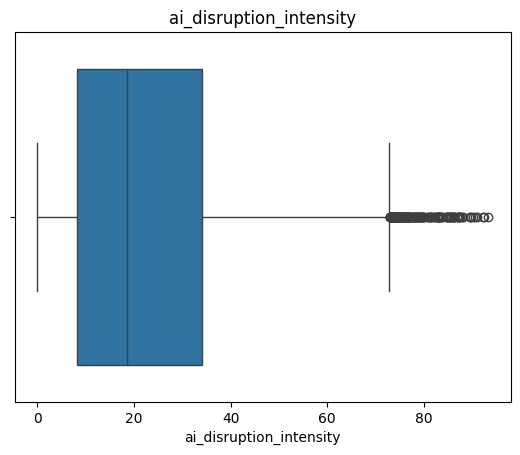

In [8]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [9]:
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

In [10]:
df_cap = df.copy()

for col in numeric_cols:
    lower = df_cap[col].quantile(0.01)
    upper = df_cap[col].quantile(0.99)
    df_cap[col] = np.clip(df_cap[col], lower, upper)

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standard = df.copy()
df_standard[numeric_cols] = scaler.fit_transform(df_standard[numeric_cols])

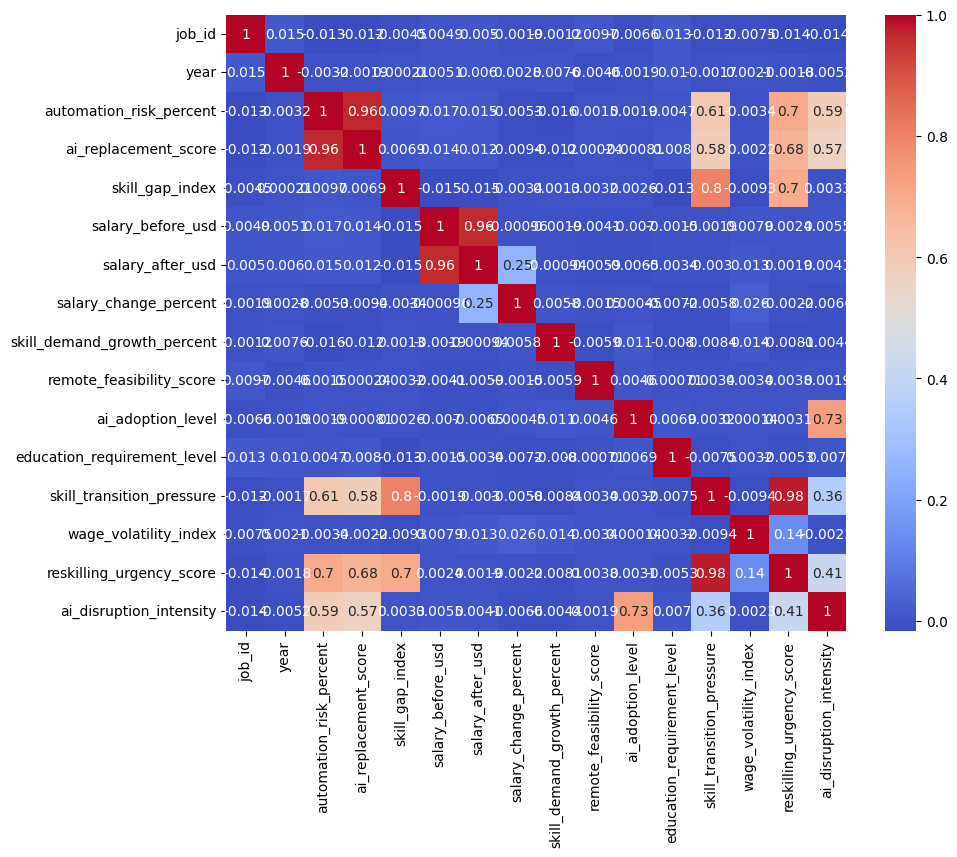

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()